***TIME SERIES FORECASTING ASSIGNMENT 2***


Problem Definition - predict and back test monthly anti-diabetic drug sales in Australia. Use the data we used in class.
Back test 12 month forecasts over 4 test periods - July 2004-June 2005, July 2005-June 2006,  July 2006-June 2007, July 2007-June 2008
Run multiple ETS and ARIMA models and evaluate them over the backtest periods.

In [5]:
#Setup, Data Loading & Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Install required libraries
!pip install statsmodels pmdarima -q

from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import time


# Load Data

df = pd.read_csv('drug_sales_australia.csv')

# Display first rows to understand structure
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nLast 5 rows:")
print(df.tail())

Shape: (204, 2)

First 5 rows:
         date     value
0  1991-07-01  3.526591
1  1991-08-01  3.180891
2  1991-09-01  3.252221
3  1991-10-01  3.611003
4  1991-11-01  3.565869

Column names: ['date', 'value']

Data types:
date      object
value    float64
dtype: object

Last 5 rows:
           date      value
199  2008-02-01  21.654285
200  2008-03-01  18.264945
201  2008-04-01  23.107677
202  2008-05-01  22.912510
203  2008-06-01  19.431740


Series range: 1991-07 to 2008-06
Total observations: 204
Test 1 (Jul04-Jun05): Train = 156 obs, Test = 12 obs
Test 2 (Jul05-Jun06): Train = 168 obs, Test = 12 obs
Test 3 (Jul06-Jun07): Train = 180 obs, Test = 12 obs
Test 4 (Jul07-Jun08): Train = 192 obs, Test = 12 obs


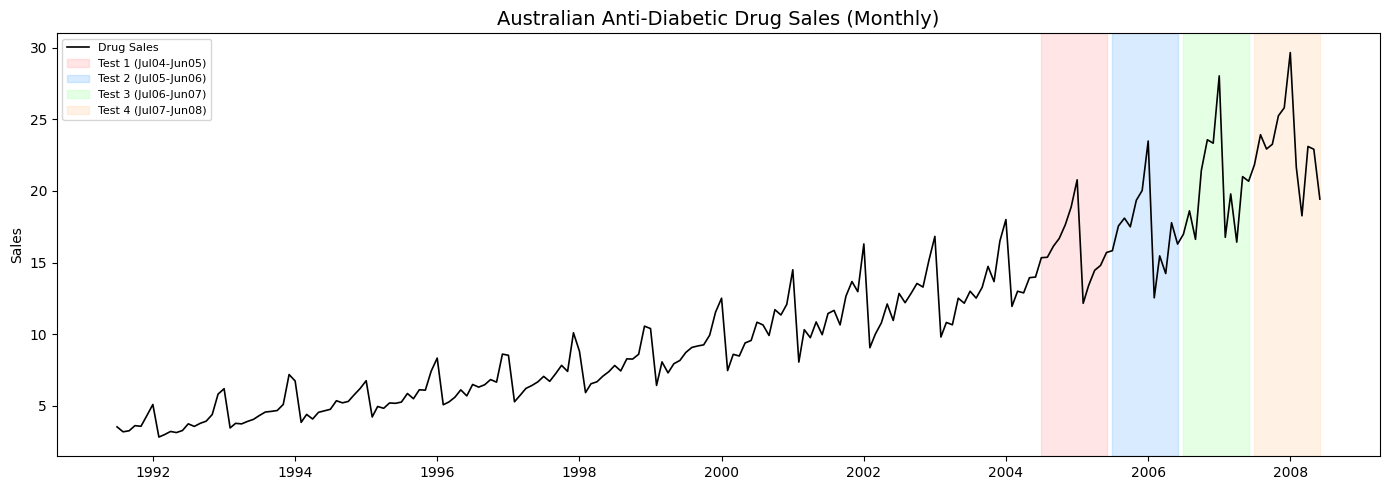

In [2]:

#Data Preparation, Time Series Setup & Visualization

# Parse dates and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.index.freq = 'MS'

y = df['value']

print(f"Series range: {y.index[0].strftime('%Y-%m')} to {y.index[-1].strftime('%Y-%m')}")
print(f"Total observations: {len(y)}")

# Define the 4 backtest periods

test_periods = {
    'Test 1 (Jul04-Jun05)': ('2004-07-01', '2005-06-01'),
    'Test 2 (Jul05-Jun06)': ('2005-07-01', '2006-06-01'),
    'Test 3 (Jul06-Jun07)': ('2006-07-01', '2007-06-01'),
    'Test 4 (Jul07-Jun08)': ('2007-07-01', '2008-06-01'),
}

# For each test period, training = everything before the test start
for name, (start, end) in test_periods.items():
    train = y[:start].iloc[:-1]  # everything before test start
    test  = y[start:end]
    print(f"{name}: Train = {len(train)} obs, Test = {len(test)} obs")

# Plot full series with backtest regions

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y, color='black', linewidth=1.2, label='Drug Sales')

colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for (name, (start, end)), color in zip(test_periods.items(), colors):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.25, color=color, label=name)

ax.set_title('Australian Anti-Diabetic Drug Sales (Monthly)', fontsize=14)
ax.set_ylabel('Sales')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**OBSERVATIONS**

Trend: There's a clear upward trend that accelerates over time — sales grow slowly in the 1990s but much faster after ~2000. This is indicative of a non linear growth. Seasonality: There is strong seasonality as well with repeating patterns every 12 months. Critically, the  these seasonal swings gets larger as the level increases. This is is indicative of a multiplicative seasonality — the seasonal effect is proportional to the level, not constant.
Since the seasonal fluctuations scale with the trend, additive models will underfit early periods and overfit late ones. Multiplicative decomposition (and multiplicative ETS models) will handle this correctly.

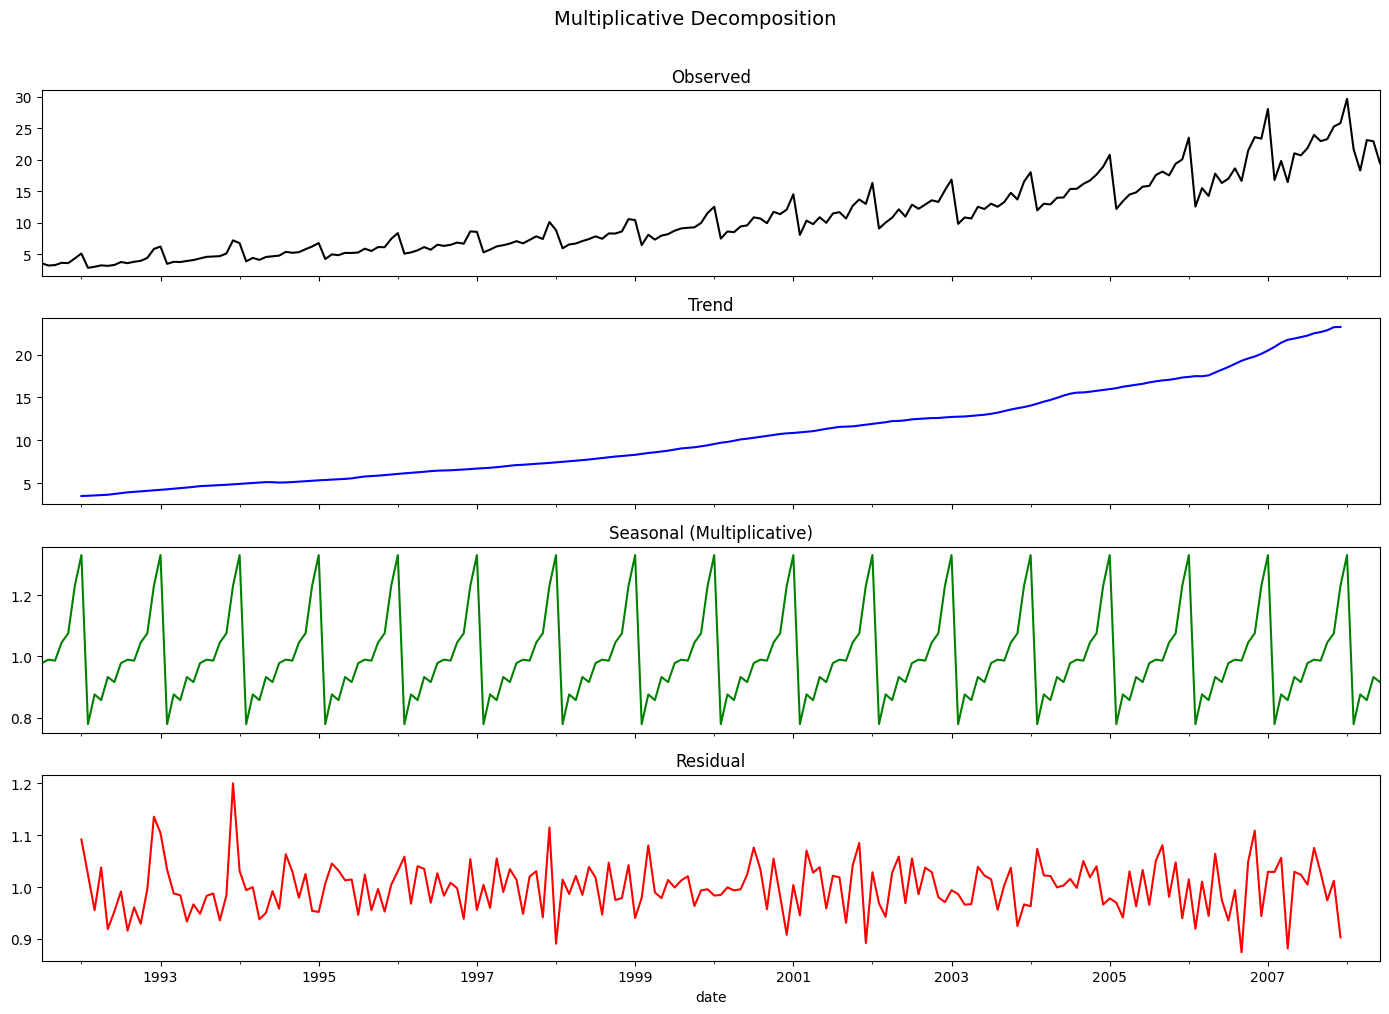


Monthly Seasonal Indices (Multiplicative):
  Jan: 1.3305  (↑ above avg)
  Feb: 0.7796  (↓ below avg)
  Mar: 0.8764  (↓ below avg)
  Apr: 0.8578  (↓ below avg)
  May: 0.9330  (↓ below avg)
  Jun: 0.9166  (↓ below avg)
  Jul: 0.9785  (↓ below avg)
  Aug: 0.9897  (↓ below avg)
  Sep: 0.9864  (↓ below avg)
  Oct: 1.0455  (↑ above avg)
  Nov: 1.0756  (↑ above avg)
  Dec: 1.2304  (↑ above avg)

STATIONARITY ANALYSIS

--- ADF Test (Original Series) ---
  Test Statistic: 3.1452
  p-value:        1.0000
  Conclusion:     NON-Stationary (α=0.05)

--- KPSS Test (Original Series) ---
  Test Statistic: 0.4615
  p-value:        0.0100
  Conclusion:     NON-Stationary (α=0.05)

--- ADF Test (After d=1, D=1 differencing) ---
  Test Statistic: -4.7834
  p-value:        0.0001
  Conclusion:     Stationary (α=0.05)

--- KPSS Test (After d=1, D=1 differencing) ---
  Test Statistic: 0.1071
  p-value:        0.1000
  Conclusion:     Stationary (α=0.05)


/tmp/ipykernel_17265/1825647417.py:45: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(y, regression='ct', nlags='auto')
/tmp/ipykernel_17265/1825647417.py:60: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff = kpss(y_diff, regression='c', nlags='auto')


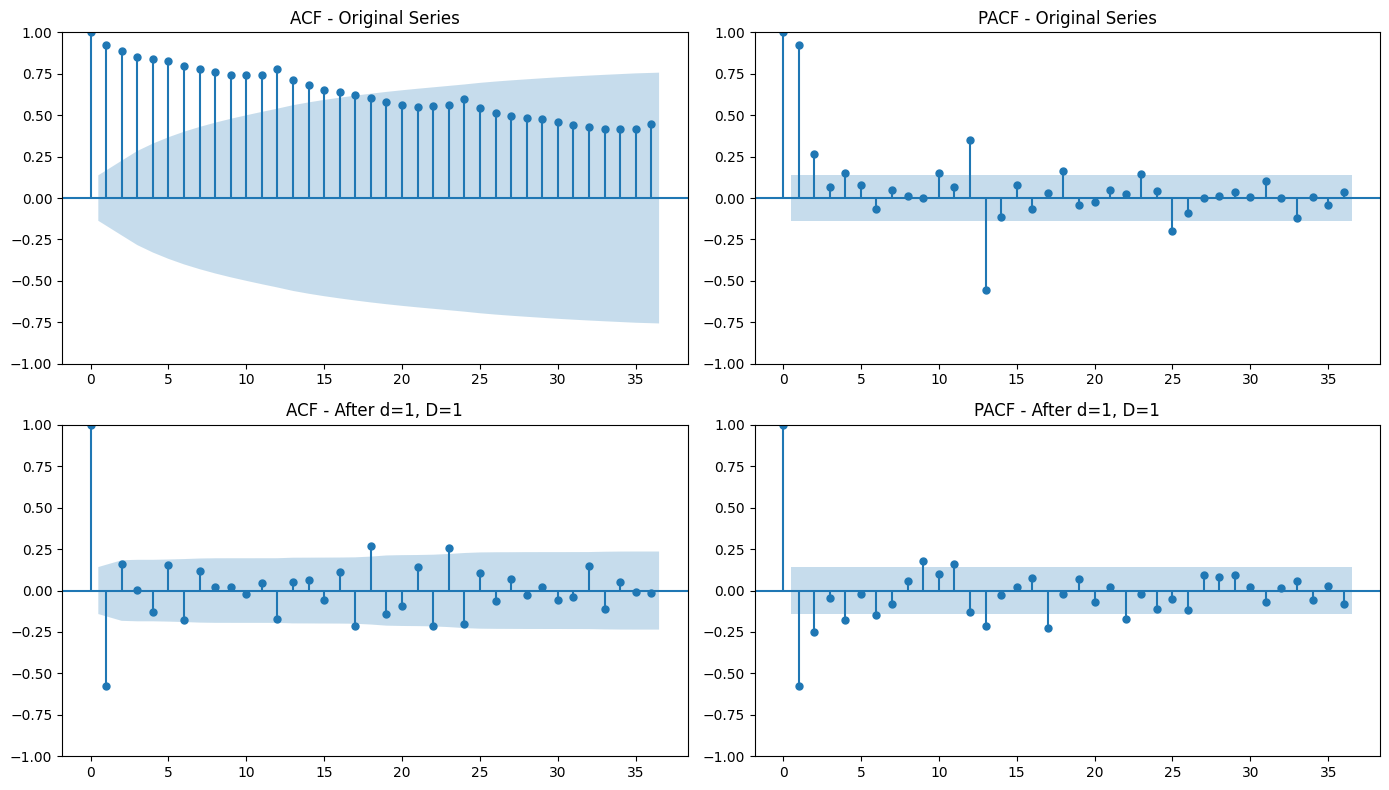

In [4]:

# : Decomposition, Stationarity & ACF/PACF Analysis

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Multiplicative Decomposition
decomp = seasonal_decompose(y, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed', color='black')
decomp.trend.plot(ax=axes[1], title='Trend', color='blue')
decomp.seasonal.plot(ax=axes[2], title='Seasonal (Multiplicative)', color='green')
decomp.resid.plot(ax=axes[3], title='Residual', color='red')
for ax in axes:
    ax.set_ylabel('')
fig.suptitle('Multiplicative Decomposition', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print seasonal indices
seasonal_indices = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
print("\nMonthly Seasonal Indices (Multiplicative):")
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
for m, name in enumerate(month_names, 1):
    print(f"  {name}: {seasonal_indices[m]:.4f}  "
          f"({'↑ above avg' if seasonal_indices[m] > 1 else '↓ below avg'})")


# 2. Stationarity Tests (on original series)

print("\n" + "="*60)
print("STATIONARITY ANALYSIS")
print("="*60)

# ADF Test (H0: series is non - stationary)
adf_result = adfuller(y, autolag='AIC')
print(f"\n--- ADF Test (Original Series) ---")
print(f"  Test Statistic: {adf_result[0]:.4f}")
print(f"  p-value:        {adf_result[1]:.4f}")
print(f"  Conclusion:     {'Stationary' if adf_result[1] < 0.05 else 'NON-Stationary'} (α=0.05)")

# KPSS Test (H0: series is stationary)
kpss_result = kpss(y, regression='ct', nlags='auto')
print(f"\n--- KPSS Test (Original Series) ---")
print(f"  Test Statistic: {kpss_result[0]:.4f}")
print(f"  p-value:        {kpss_result[1]:.4f}")
print(f"  Conclusion:     {'Stationary' if kpss_result[1] > 0.05 else 'NON-Stationary'} (α=0.05)")

# test after differencing
y_diff = y.diff(1).diff(12).dropna()

adf_diff = adfuller(y_diff, autolag='AIC')
print(f"\n--- ADF Test (After d=1, D=1 differencing) ---")
print(f"  Test Statistic: {adf_diff[0]:.4f}")
print(f"  p-value:        {adf_diff[1]:.4f}")
print(f"  Conclusion:     {'Stationary' if adf_diff[1] < 0.05 else 'NON-Stationary'} (α=0.05)")

kpss_diff = kpss(y_diff, regression='c', nlags='auto')
print(f"\n--- KPSS Test (After d=1, D=1 differencing) ---")
print(f"  Test Statistic: {kpss_diff[0]:.4f}")
print(f"  p-value:        {kpss_diff[1]:.4f}")
print(f"  Conclusion:     {'Stationary' if kpss_diff[1] > 0.05 else 'NON-Stationary'} (α=0.05)")

# 3. ACF & PACF Plots (differenced series)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original series
plot_acf(y, lags=36, ax=axes[0, 0], title='ACF - Original Series')
plot_pacf(y, lags=36, ax=axes[0, 1], title='PACF - Original Series')

# Differenced series (d=1, D=1)
plot_acf(y_diff, lags=36, ax=axes[1, 0], title='ACF - After d=1, D=1')
plot_pacf(y_diff, lags=36, ax=axes[1, 1], title='PACF - After d=1, D=1')

plt.tight_layout()
plt.show()



The seasonal component confirms the pattern is multiplicative; the seasonal indices ranges from 0.78 to 1.33, meaning they act as multipliers. The original series is confirmed as non-stationary as both tests agree. When the difference is applied (regular and seasonal difference) both tests flip. This confirms that our model needs to be seasonal and the acf / pacf plots point to a SARIMA model (0,1,1) , (0,1,1) [12].

In [6]:

# Model Definitions & Backtesting Loop

import time
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima


# Define all models as functions

def fit_ets_AAA(train):
    """ETS(A,A,A) - Additive error, Additive trend, Additive seasonality"""
    model = ExponentialSmoothing(train, trend='add', seasonal='add',
                                 seasonal_periods=12).fit(optimized=True)
    return model.forecast(12)

def fit_ets_AAd(train):
    """ETS(A,Ad,A) - Additive error, Damped Additive trend, Additive seasonality"""
    model = ExponentialSmoothing(train, trend='add', seasonal='add',
                                 seasonal_periods=12, damped_trend=True).fit(optimized=True)
    return model.forecast(12)

def fit_ets_MAM(train):
    """ETS(M,A,M) - Multiplicative error, Additive trend, Multiplicative seasonality"""
    model = ExponentialSmoothing(train, trend='add', seasonal='mul',
                                 seasonal_periods=12).fit(optimized=True)
    return model.forecast(12)

def fit_ets_MAMd(train):
    """ETS(M,Ad,M) - Multiplicative error, Damped Additive trend, Multiplicative seasonality"""
    model = ExponentialSmoothing(train, trend='add', seasonal='mul',
                                 seasonal_periods=12, damped_trend=True).fit(optimized=True)
    return model.forecast(12)

def fit_ets_MMM(train):
    """ETS(M,M,M) - Multiplicative error, Multiplicative trend, Multiplicative seasonality"""
    model = ExponentialSmoothing(train, trend='mul', seasonal='mul',
                                 seasonal_periods=12).fit(optimized=True)
    return model.forecast(12)

def fit_ets_MMMd(train):
    """ETS(M,Md,M) - Multiplicative error, Damped Multiplicative trend, Multiplicative seasonality"""
    model = ExponentialSmoothing(train, trend='mul', seasonal='mul',
                                 seasonal_periods=12, damped_trend=True).fit(optimized=True)
    return model.forecast(12)

def fit_arima_011_011(train):
    """SARIMA(0,1,1)(0,1,1)[12] - Airline Model"""
    model = SARIMAX(train, order=(0,1,1), seasonal_order=(0,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return model.forecast(12)

def fit_arima_110_110(train):
    """SARIMA(1,1,0)(1,1,0)[12] - Pure AR model"""
    model = SARIMAX(train, order=(1,1,0), seasonal_order=(1,1,0,12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return model.forecast(12)

def fit_arima_111_011(train):
    """SARIMA(1,1,1)(0,1,1)[12]"""
    model = SARIMAX(train, order=(1,1,1), seasonal_order=(0,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return model.forecast(12)

def fit_arima_011_110(train):
    """SARIMA(0,1,1)(1,1,0)[12]"""
    model = SARIMAX(train, order=(0,1,1), seasonal_order=(1,1,0,12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return model.forecast(12)

def fit_arima_auto(train):
    """Auto ARIMA - let pmdarima find the best model"""
    auto_model = auto_arima(train, seasonal=True, m=12,
                            d=1, D=1,
                            max_p=3, max_q=3, max_P=2, max_Q=2,
                            stepwise=True, suppress_warnings=True,
                            error_action='ignore')
    print(f"    Auto ARIMA selected: {auto_model.summary().tables[0]}")
    return auto_model.predict(n_periods=12)


#models
models = {
    'ETS(A,A,A)':        fit_ets_AAA,
    'ETS(A,Ad,A)':       fit_ets_AAd,
    'ETS(M,A,M)':        fit_ets_MAM,
    'ETS(M,Ad,M)':       fit_ets_MAMd,
    'ETS(M,M,M)':        fit_ets_MMM,
    'ETS(M,Md,M)':       fit_ets_MMMd,
    'SARIMA(0,1,1)(0,1,1)': fit_arima_011_011,
    'SARIMA(1,1,0)(1,1,0)': fit_arima_110_110,
    'SARIMA(1,1,1)(0,1,1)': fit_arima_111_011,
    'SARIMA(0,1,1)(1,1,0)': fit_arima_011_110,
    'Auto ARIMA':        fit_arima_auto,
}

# Backtesting Loop
results = []
forecasts_all = {}

print("="*70)
print("BACKTESTING: 12-month forecasts across 4 test periods")
print("="*70)

for period_name, (test_start, test_end) in test_periods.items():
    print(f"\n{'─'*70}")
    print(f"  {period_name}")
    print(f"{'─'*70}")

    train = y[:test_start].iloc[:-1]
    test  = y[test_start:test_end]

    for model_name, model_func in models.items():
        try:
            start_time = time.time()
            print(f"  Fitting {model_name}...", end=" ")

            forecast = model_func(train)

            # Align forecast index with test index
            forecast = pd.Series(forecast.values, index=test.index)

            elapsed = time.time() - start_time

            # Calculate error metrics
            mae  = mean_absolute_error(test, forecast)
            rmse = np.sqrt(mean_squared_error(test, forecast))
            mape = mean_absolute_percentage_error(test, forecast) * 100

            results.append({
                'Period': period_name,
                'Model': model_name,
                'MAE': mae,
                'RMSE': rmse,
                'MAPE': mape,
            })

            # Store forecasts for plotting later
            forecasts_all[(period_name, model_name)] = forecast

            print(f"Done ({elapsed:.1f}s) | MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.1f}%")

        except Exception as e:
            print(f"FAILED: {e}")
            results.append({
                'Period': period_name,
                'Model': model_name,
                'MAE': np.nan,
                'RMSE': np.nan,
                'MAPE': np.nan,
            })


# Summary Table
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("AVERAGE METRICS ACROSS ALL 4 BACKTEST PERIODS")
print("="*70)
avg_metrics = results_df.groupby('Model')[['MAE','RMSE','MAPE']].mean().sort_values('MAPE')
print(avg_metrics.round(3).to_string())

print("\n\nBest model by avg MAPE:", avg_metrics.index[0])
print(f"  Avg MAE:  {avg_metrics.iloc[0]['MAE']:.3f}")
print(f"  Avg RMSE: {avg_metrics.iloc[0]['RMSE']:.3f}")
print(f"  Avg MAPE: {avg_metrics.iloc[0]['MAPE']:.2f}%")

BACKTESTING: 12-month forecasts across 4 test periods

──────────────────────────────────────────────────────────────────────
  Test 1 (Jul04-Jun05)
──────────────────────────────────────────────────────────────────────
  Fitting ETS(A,A,A)... Done (0.3s) | MAE=0.93, RMSE=1.04, MAPE=5.8%
  Fitting ETS(A,Ad,A)... Done (0.5s) | MAE=0.90, RMSE=1.01, MAPE=5.7%
  Fitting ETS(M,A,M)... Done (0.4s) | MAE=0.67, RMSE=0.80, MAPE=4.2%
  Fitting ETS(M,Ad,M)... Done (0.4s) | MAE=0.67, RMSE=0.79, MAPE=4.1%
  Fitting ETS(M,M,M)... Done (0.6s) | MAE=0.53, RMSE=0.64, MAPE=3.4%
  Fitting ETS(M,Md,M)... Done (0.9s) | MAE=0.50, RMSE=0.62, MAPE=3.3%
  Fitting SARIMA(0,1,1)(0,1,1)... Done (0.6s) | MAE=1.00, RMSE=1.13, MAPE=6.1%
  Fitting SARIMA(1,1,0)(1,1,0)... Done (0.3s) | MAE=0.89, RMSE=1.06, MAPE=5.7%
  Fitting SARIMA(1,1,1)(0,1,1)... Done (0.9s) | MAE=0.92, RMSE=1.04, MAPE=5.7%
  Fitting SARIMA(0,1,1)(1,1,0)... Done (0.4s) | MAE=0.99, RMSE=1.14, MAPE=6.2%
  Fitting Auto ARIMA...     Auto ARIMA selected

The top models are all ETS models with multiplicative seasonality (M,M,M), (M, Md, M), (M,A,M), (M,Ad,M). This validates what we observed in the decomposition analysis. Judging the models by avg mape, we see, ETS(M,Md,M) wins by a narrow margin over ETS(M,M,M). The damped multiplicative trend slightly edges out the undamped version. Backtesting across the 4 time periods, reveals that the metrics began worsening while forecasting for test period 3 and if we look at the original plot, there's a noticeable acceleration in the series around 2006-2007 with some large spikes.

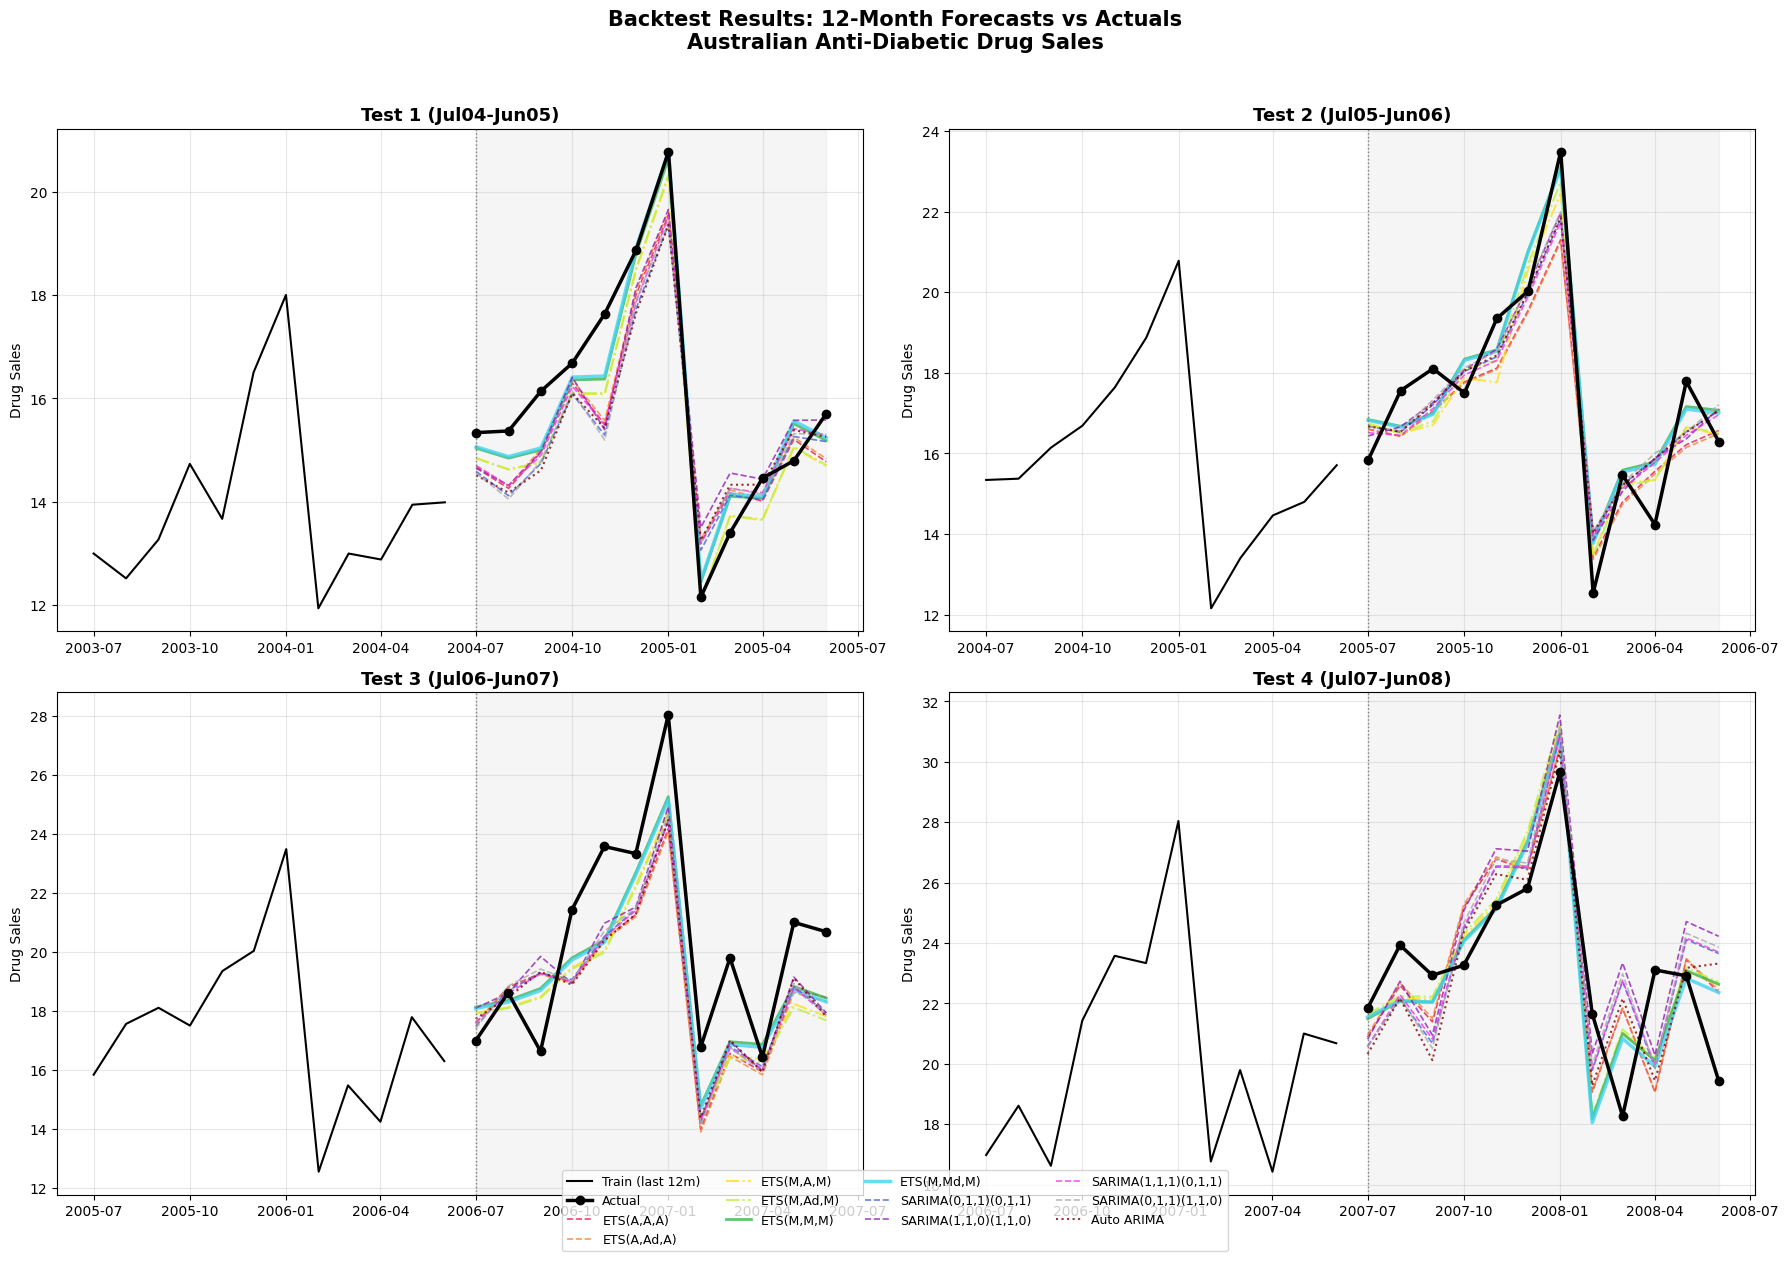

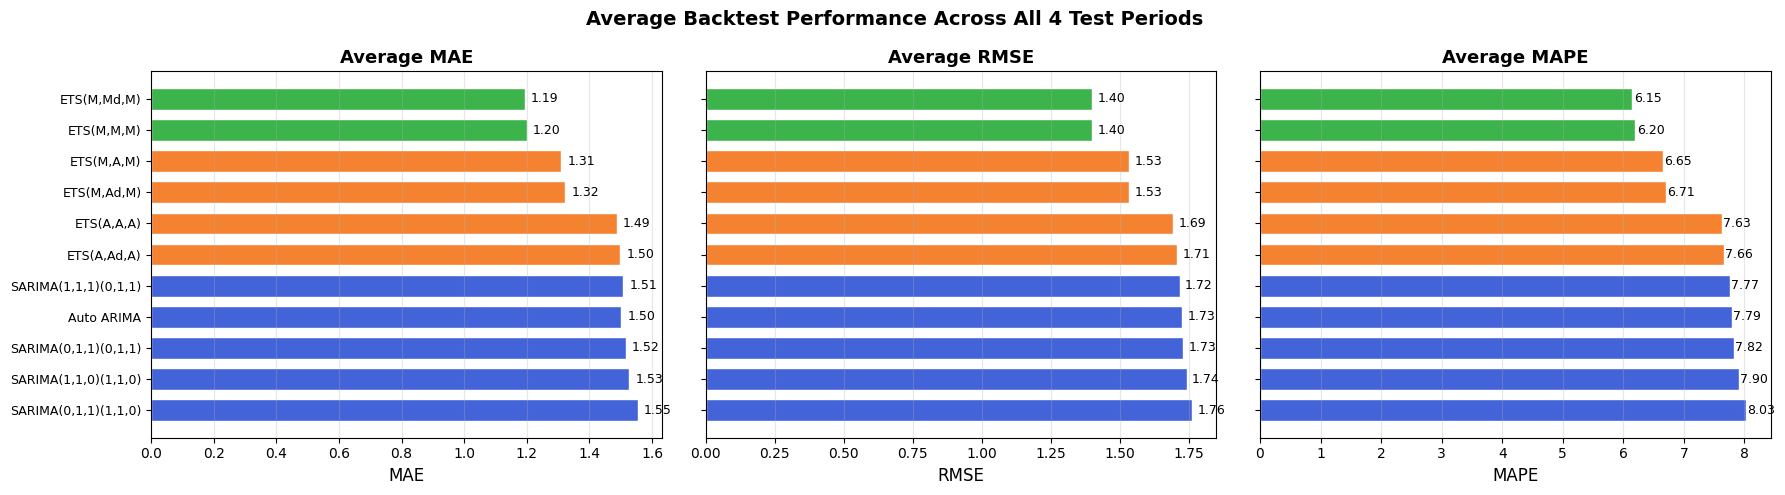

  • backtest_panels.png  - Forecasts vs Actuals per period
  • backtest_bars.png    - Average metric comparison bars


In [9]:

#Visualization - Backtest Forecast vs Actuals


# PLOT 1: Panel plot - one subplot per test period

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Color scheme
model_styles = {
    'ETS(A,A,A)':              {'color': '#e6194b', 'ls': '--',  'lw': 1.2},
    'ETS(A,Ad,A)':             {'color': '#f58231', 'ls': '--',  'lw': 1.2},
    'ETS(M,A,M)':              {'color': '#ffe119', 'ls': '-.',  'lw': 1.5},
    'ETS(M,Ad,M)':             {'color': '#bfef45', 'ls': '-.',  'lw': 1.5},
    'ETS(M,M,M)':              {'color': '#3cb44b', 'ls': '-',   'lw': 2.0},
    'ETS(M,Md,M)':             {'color': '#42d4f4', 'ls': '-',   'lw': 2.5},  # BEST - thick
    'SARIMA(0,1,1)(0,1,1)':    {'color': '#4363d8', 'ls': '--',  'lw': 1.2},
    'SARIMA(1,1,0)(1,1,0)':    {'color': '#911eb4', 'ls': '--',  'lw': 1.2},
    'SARIMA(1,1,1)(0,1,1)':    {'color': '#f032e6', 'ls': '--',  'lw': 1.2},
    'SARIMA(0,1,1)(1,1,0)':    {'color': '#a9a9a9', 'ls': '--',  'lw': 1.2},
    'Auto ARIMA':              {'color': '#800000', 'ls': ':',    'lw': 1.5},
}

for idx, (period_name, (test_start, test_end)) in enumerate(test_periods.items()):
    ax = axes[idx]
    test = y[test_start:test_end]

    # Plot some training context
    context_start = pd.Timestamp(test_start) - pd.DateOffset(months=12)
    context = y[context_start:test_start].iloc[:-1]

    ax.plot(context.index, context.values, color='black', lw=1.5, label='Train (last 12m)')
    ax.plot(test.index, test.values, color='black', lw=2.5, marker='o',
            markersize=6, label='Actual', zorder=10)

    # Plot each model's forecast
    for model_name, style in model_styles.items():
        key = (period_name, model_name)
        if key in forecasts_all:
            fc = forecasts_all[key]
            ax.plot(fc.index, fc.values,
                    color=style['color'], ls=style['ls'], lw=style['lw'],
                    alpha=0.8, label=model_name)

    # Shade test region
    ax.axvspan(pd.Timestamp(test_start), pd.Timestamp(test_end), alpha=0.08, color='gray')
    ax.axvline(pd.Timestamp(test_start), color='gray', ls=':', lw=1)

    ax.set_title(period_name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Drug Sales')
    ax.grid(True, alpha=0.3)

# Single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

fig.suptitle('Backtest Results: 12-Month Forecasts vs Actuals\nAustralian Anti-Diabetic Drug Sales',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('backtest_panels.png', dpi=150, bbox_inches='tight')
plt.show()



# PLOT 2: Bar chart - Average metrics comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors_bar = ['#3cb44b' if 'M,M' in m or 'Md,M' in m
              else '#4363d8' if 'SARIMA' in m or 'Auto' in m
              else '#f58231' for m in avg_metrics.index]

for i, metric in enumerate(metrics):
    bars = axes[i].barh(range(len(avg_metrics)), avg_metrics[metric],
                         color=colors_bar, edgecolor='white', height=0.7)
    axes[i].set_yticks(range(len(avg_metrics)))
    axes[i].set_yticklabels(avg_metrics.index if i == 0 else [], fontsize=9)
    axes[i].set_xlabel(metric, fontsize=12)
    axes[i].set_title(f'Average {metric}', fontsize=13, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].grid(True, axis='x', alpha=0.3)

    # Annotate bars
    for bar, val in zip(bars, avg_metrics[metric]):
        axes[i].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}', va='center', fontsize=9)

fig.suptitle('Average Backtest Performance Across All 4 Test Periods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('backtest_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print("  • backtest_panels.png  - Forecasts vs Actuals per period")
print("  • backtest_bars.png    - Average metric comparison bars")

MODEL SELECTION: ETS(M,Md,M)
Multiplicative Error, Damped Multiplicative Trend,
Multiplicative Seasonality

WHY ETS(M,Md,M)?

1. BEST OVERALL BACKTEST PERFORMANCE:
   - Lowest average MAPE: 6.15% across all 4 test periods
   - Lowest average MAE:  1.194
   - Lowest average RMSE: 1.400
   It ranked #1 on ALL three error metrics consistently.

2. MULTIPLICATIVE SEASONALITY IS CORRECT FOR THIS DATA:
   - The decomposition showed seasonal amplitude grows proportionally
     with the trend (indices range from 0.78 to 1.33)
   - Additive models (ETS AAA, ARIMA) systematically underperform
     because they assume constant seasonal swings
   - All top-4 models use multiplicative seasonality

3. CONSISTENCY ACROSS TEST PERIODS:
   - M,Md,M was top-2 in every single test period
   - It performed well in both "easy" periods (Test 1-2) and
     the "hard" period (Test 3) where all models struggled

4. ARIMA LIMITATION:
   - SARIMA models are inherently additive and cannot natively
     capture mu

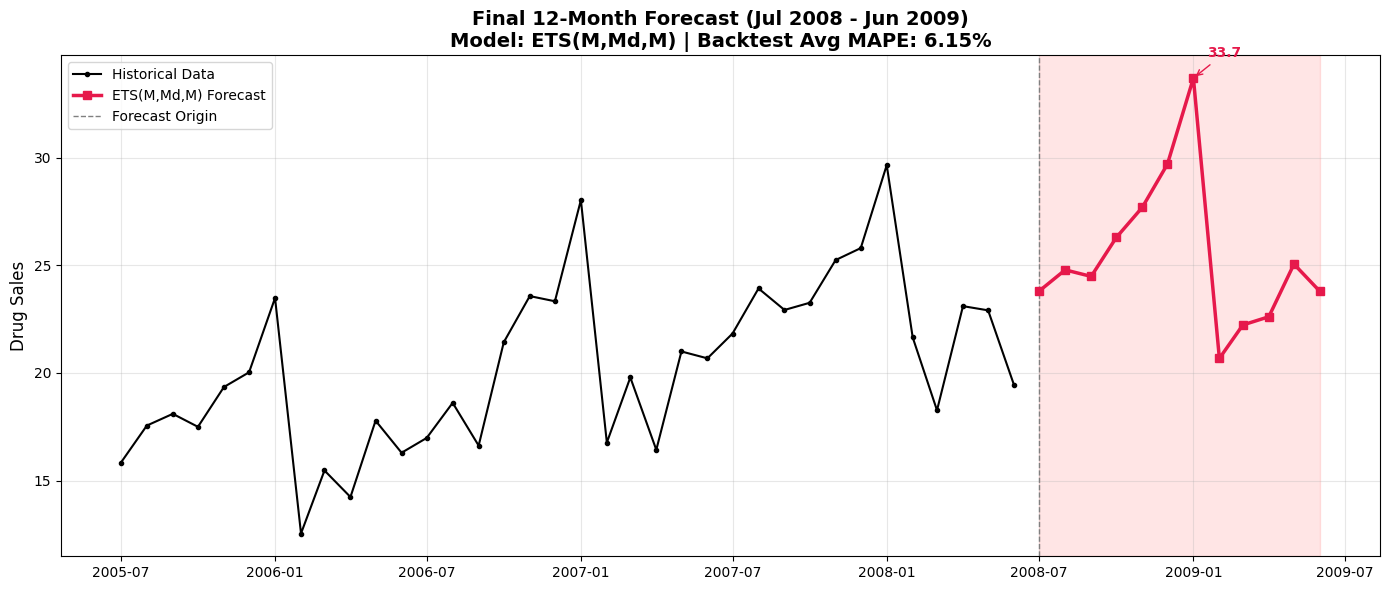


Forecast plot saved as 'final_forecast.png'


In [10]:

#Final Model Selection & 12-Month Forecast


# 1. Justification Summary
print("="*70)
print("MODEL SELECTION: ETS(M,Md,M)")
print("Multiplicative Error, Damped Multiplicative Trend,")
print("Multiplicative Seasonality")
print("="*70)

print("""
WHY ETS(M,Md,M)?

1. BEST OVERALL BACKTEST PERFORMANCE:
   - Lowest average MAPE: 6.15% across all 4 test periods
   - Lowest average MAE:  1.194
   - Lowest average RMSE: 1.400
   It ranked #1 on ALL three error metrics consistently.

2. MULTIPLICATIVE SEASONALITY IS CORRECT FOR THIS DATA:
   - The decomposition showed seasonal amplitude grows proportionally
     with the trend (indices range from 0.78 to 1.33)
   - Additive models (ETS AAA, ARIMA) systematically underperform
     because they assume constant seasonal swings
   - All top-4 models use multiplicative seasonality

3. CONSISTENCY ACROSS TEST PERIODS:
   - M,Md,M was top-2 in every single test period
   - It performed well in both "easy" periods (Test 1-2) and
     the "hard" period (Test 3) where all models struggled

4. ARIMA LIMITATION:
   - SARIMA models are inherently additive and cannot natively
     capture multiplicative seasonality
   - Even Auto ARIMA with flexible order selection couldn't
     compete with the multiplicative ETS family
""")


# 2. Fit final model on ALL data & forecast next 12 months
print("\n" + "="*70)
print("FINAL FORECAST: July 2008 - June 2009")
print("="*70)

final_model = ExponentialSmoothing(
    y,
    trend='mul',
    seasonal='mul',
    seasonal_periods=12,
    damped_trend=True
).fit(optimized=True)

# Print model parameters
print(f"\nFitted Parameters:")
print(f"  Alpha (level):    {final_model.params['smoothing_level']:.4f}")
print(f"  Beta  (trend):    {final_model.params['smoothing_trend']:.4f}")
print(f"  Gamma (seasonal): {final_model.params['smoothing_seasonal']:.4f}")
print(f"  Phi   (damping):  {final_model.params['damping_trend']:.4f}")

forecast_final = final_model.forecast(12)
forecast_index = pd.date_range(start='2008-07-01', periods=12, freq='MS')
forecast_final.index = forecast_index

print(f"\n{'Month':<15} {'Forecast':>10}")
print("-" * 27)
for date, val in forecast_final.items():
    print(f"  {date.strftime('%b %Y'):<13} {val:>10.2f}")


# 4. Plot final forecast

fig, ax = plt.subplots(figsize=(14, 6))

# Plot last 3 years of history + forecast
history_start = '2005-07-01'
ax.plot(y[history_start:], color='black', lw=1.5, marker='o',
        markersize=3, label='Historical Data')
ax.plot(forecast_final, color='#e6194b', lw=2.5, marker='s',
        markersize=6, label='ETS(M,Md,M) Forecast', zorder=5)

# Shade forecast region
ax.axvspan(forecast_final.index[0], forecast_final.index[-1],
           alpha=0.1, color='red')
ax.axvline(forecast_final.index[0], color='gray', ls='--', lw=1,
           label='Forecast Origin')

# Annotate key months
jan_idx = [i for i, d in enumerate(forecast_final.index) if d.month == 1]
for i in jan_idx:
    ax.annotate(f'{forecast_final.iloc[i]:.1f}',
                xy=(forecast_final.index[i], forecast_final.iloc[i]),
                xytext=(10, 15), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#e6194b',
                arrowprops=dict(arrowstyle='->', color='#e6194b'))

ax.set_title('Final 12-Month Forecast (Jul 2008 - Jun 2009)\nModel: ETS(M,Md,M) | Backtest Avg MAPE: 6.15%',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Drug Sales', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nForecast plot saved as 'final_forecast.png'")

I would pick the ETS(M,Md,M) as this wins across all the models tested and because the data's fundamental characteristics, which include growing trend with proportionally increasing seasonal swings are exactly what this model is designed for. The multiplicative components match the data's structure, and the damped trend adds a layer of conservatism that improved forecast accuracy over 12-month horizons. ARIMA models are structurally disadvantaged here because they can't natively handle multiplicative seasonality.